In [1]:
from pathlib import Path
import yaml
import numpy as np
from astropy import stats
from astropy.time import Time
from astropy.table import Table, MaskedColumn
from kpf_etc.etc import kpf_photon_noise_estimate

import matplotlib.pyplot as plt

data_file = 'data/Feb2026_withInstZPs.csv'
t = Table.read(data_file, format='ascii.csv')

In [2]:
EMZPfile = Path('data/ExposureMeterZeroPoints.yaml')
with open(EMZPfile, 'r') as f:
    EMZeroPoint = yaml.safe_load(f)
EMZeroPoint

{1: 21.296861833059204,
 2: 21.802875631774594,
 3: 21.73859924329517,
 4: 21.385171098414354,
 'SUM': 23.06521519492087}

In [3]:
ZPfile = Path('data/InstrumentZeroPoints.yaml')
with open(ZPfile, 'r') as f:
    ZeroPoint = yaml.safe_load(f)
ZeroPoint

{'452': 13.664362089856091,
 '548': 14.964690898633878,
 '652': 15.329155098901115,
 '747': 15.466755734095996,
 '852': 15.073233551565435}

In [4]:
EMbinfile = Path('data/ExpMeterBins.yaml')
with open(EMbinfile, 'r') as f:
    best_EMbin = yaml.safe_load(f)
best_EMbin

{'452': 1, '548': 2, '652': 3, '747': 4, '852': 4}

In [5]:
wavs = ZeroPoint.keys()
EMbins = EMZeroPoint.keys()

# Use "Nominal" Zero Point Value as an ETC

A Zero Point is a simple ETC as, by definition, it is the magnitude at which you will get a flux of 1 per second of whatever flux units you used to calculate the zero point.  In our case, this is detected photons per pixel for the spectrograph and total ADU in the wavelength bin for the Exposure Meter.

We will use the comparison of the ETC predictions to the actual measured flux to measure the slowdown factor which is of interest to KPF-CC scheduling.

In [6]:
def ZPETC(Gmag, exptime, wav='652', EMbin=2):
    assert wav in ZeroPoint.keys()
    assert EMbin in EMZeroPoint.keys()
    photons = float(exptime*10**((Gmag - ZeroPoint[wav])/-2.5))
    EM_ADU = float(exptime*10**((Gmag - EMZeroPoint[EMbin])/-2.5))
    return photons, EM_ADU


def EMThreshold(photons, wav='652', EMbin=2):
    assert wav in ZeroPoint.keys()
    assert EMbin in EMZeroPoint.keys()
    ZPdiff = ZeroPoint[wav] - EMZeroPoint[EMbin]
    EM_ADU = photons*10**(-ZPdiff/2.5)
    return EM_ADU

In [7]:
# Double Check Consistency
photons, EMADU = ZPETC(10, 60, wav='747', EMbin=2)
EMADU2 = EMThreshold(photons, wav='747', EMbin=2)
EMADU2/EMADU

1.0

## Add Zero Point ETC results to table for both instrument and exposure meter

In [8]:
for wav in wavs:
    t.add_column(MaskedColumn(t['ELAPSED']*10**((t['GAIAMAG'] - ZeroPoint[wav])/-2.5), name=f'ZP-etc-{wav}'))
    t[f'ZP-etc-{wav}'].mask = t[f'ZP-etc-{wav}'].mask | (t[f'ZP-etc-{wav}'] <= 0)
    slowdown = t[f'ZP-etc-{wav}']/t[f'SNRSC{wav}']**2
    t.add_column(MaskedColumn(slowdown, name=f'SD-ZP-etc-{wav}'))
    t[f'SD-ZP-etc-{wav}'].mask = t[f'SD-ZP-etc-{wav}'].mask | t[f'ZP-etc-{wav}'].mask | (t[f'SD-ZP-etc-{wav}'] > 10)

In [9]:
for EMbin in EMbins:
    t.add_column(MaskedColumn(t['ELAPSED']*10**((t['GAIAMAG'] - EMZeroPoint[EMbin])/-2.5), name=f'ZP-etc-EM{EMbin}'))
    t[f'ZP-etc-EM{EMbin}'].mask = t[f'ZP-etc-EM{EMbin}'].mask | (t[f'ZP-etc-EM{EMbin}'] <= 0)
    slowdown = t[f'ZP-etc-EM{EMbin}']/t[f'TOTCORR_{EMbin}']
    t.add_column(MaskedColumn(slowdown, name=f'SD-ZP-etc-EM{EMbin}'))
    t[f'SD-ZP-etc-EM{EMbin}'].mask = t[f'SD-ZP-etc-EM{EMbin}'].mask | t[f'ZP-etc-EM{EMbin}'].mask | (t[f'SD-ZP-etc-EM{EMbin}'] > 10)

## Add in results of formal KPF-etc

In [10]:
def read_GminusV_table():
    '''Table of data from:
    https://www.pas.rochester.edu/~emamajek/EEM_dwarf_UBVIJHK_colors_Teff.txt
    '''
    table_file = Path('data/EEM_dwarf_UBVIJHK_colors_Teff.txt')
    if table_file.exists() is False:
        return 0
    t = Table.read(table_file, format='ascii')
    filtered = t[t['G-V'] != '...']
    return filtered

filtered = read_GminusV_table()

def get_GminusV(Teff):
    Teff_diff = abs(filtered['Teff'] - Teff)
    ind = np.argmin(Teff_diff)
    GminusV = float(filtered[ind]['G-V'])
    return GminusV

def Vmag(Gmag, Teff):
    return Gmag - get_GminusV(Teff)

In [11]:
# Add Vmag as column
vmag_data = [Vmag(row['GAIAMAG'], row['TARGTEFF']) for row in t]
t.add_column(MaskedColumn(vmag_data, name=f'VMAG'))

In [12]:
# Add ETC results as columns
order = {'452': 2,
         '548': 25,
         '652': 43,
         '747': 55,
         '852': 65}
ETCflux = {'452': [],
           '548': [],
           '652': [],
           '747': [],
           '852': []}
ETC_SD = {'452': [],
          '548': [],
          '652': [],
          '747': [],
          '852': []}

ETCvalid = (t['TARGTEFF'] >= 2700) & (t['TARGTEFF'] <= 6600) & (t['ELAPSED'] > 10) & (t['ELAPSED'] <= 3600)
for i,row in enumerate(t):
    # KPF-etc
    if ETCvalid[i] == True:
        try:
            a, b, snr_ord, c = kpf_photon_noise_estimate(row['TARGTEFF'], row['VMAG'], row['ELAPSED'], quiet=True)
            for wav in wavs:
                predicted_flux = float(snr_ord[order[wav]]**2)
                ETCflux[wav].append(predicted_flux)
                slowdown = predicted_flux/float(row[f'SNRSC{wav}']**2)
                ETC_SD[wav].append(slowdown)
        except Exception as e:
            print(e, row['TARGTEFF'], row['VMAG'], row['ELAPSED'])
            for wav in wavs:
                ETCflux[wav].append(0)
                ETC_SD[wav].append(0)
    else:
        for wav in wavs:
            ETCflux[wav].append(0)
            ETC_SD[wav].append(0)

for wav in wavs:
    t.add_column(MaskedColumn(ETCflux[wav], name=f'KPF-etc-{wav}'))
    t[f'KPF-etc-{wav}'].mask = (t[f'KPF-etc-{wav}'] <= 0)
    t.add_column(MaskedColumn(ETC_SD[wav], name=f'SD-KPF-etc-{wav}'))
    t[f'SD-KPF-etc-{wav}'].mask = (t[f'SD-KPF-etc-{wav}'] <= 0) | (t[f'SD-KPF-etc-{wav}'] > 10)


/var/folders/3m/rvt2qsdx3nv0cv6m5rvbbgzc0000gp/T/ipykernel_49344/848789479.py:27: UserWarning: Warning: converting a masked element to nan.
  slowdown = predicted_flux/float(row[f'SNRSC{wav}']**2)


# Slowdown Factor

How well does the nominal flux estimate from our Zero Point based ETC predict the actual/measured flux in the data set?  To examine this, we look at the slowdown factor which is the ratio of the flux expected versus the flux measured.  The slowdown can be calculated for the instrument flux and for the Exposure Meter flux, so we want to see how well the Exposure Meter slowdown predicts the spectrograph slow down.

During night opbservations, the Exposure Meter slowdown factor could be calculated in real time, but the spectrograph slowdown factor will only be available once the DRP has run and provided the `SNRSC*` keyword values.

We can use either the Zero Point ETC or the formal KPF-etc (when the target is within its input ranges) to calculate a slowdown factor for the spectrograph, so we will examine both.

In [13]:
def plot_one_slowdown(slowdowns, bins=np.arange(0,10+0.05,0.05), color='b', label='Spectrograph'):
    plt.hist(slowdowns, bins=bins, density=True, color=color, label=label)
    n, binedges = np.histogram(slowdowns, bins=[0,1,2,4,1e6])
    d = [val/np.sum(n) for val in n]
    plt.axvspan(0, 1, color='k', alpha=0.01, label=f'band0 {d[0]:.1%}')
    plt.axvspan(1, 2, color='g', alpha=0.2, label=f'band1 {d[1]:.1%}')
    plt.axvspan(2, 4, color='y', alpha=0.2, label=f'band2 {d[2]:.1%}')
    plt.axvspan(4, 10, color='r', alpha=0.1, label=f'band3 {d[3]:.1%}')
    plt.grid()
    plt.legend(loc='best')
    plt.ylabel(f'Density')


def plot_slowdowns(t, wav):
    EMbin = best_EMbin[wav]
    bins = np.arange(0,10+0.05,0.05)
    
    plt.figure(figsize=(10,6))
    
    plt.subplot(3,1,1)
    ZPETCslowdowns = t[f'SD-ZP-etc-{wav}'][~t[f'SD-ZP-etc-{wav}'].mask]
    plt.title(f'Instrument Slowdowns Calculated at {wav} nm')
    plot_one_slowdown(ZPETCslowdowns, bins=bins, color='b', label='Spectrograph')
    
    plt.subplot(3,1,2)
    EM_ZPETCslowdowns = t[f'SD-ZP-etc-EM{EMbin}'][~t[f'SD-ZP-etc-EM{EMbin}'].mask]
    plot_one_slowdown(EM_ZPETCslowdowns, bins=bins, color='g', label='ExpMeter')
       
    plt.subplot(3,1,3)
    KPFETCslowdowns = t[f'SD-KPF-etc-{wav}'][~t[f'SD-KPF-etc-{wav}'].mask]
    plot_one_slowdown(KPFETCslowdowns, bins=bins, color='c', label='KPF-etc')
    plt.xlabel('Slowdown Factor')
    
    plt.show()

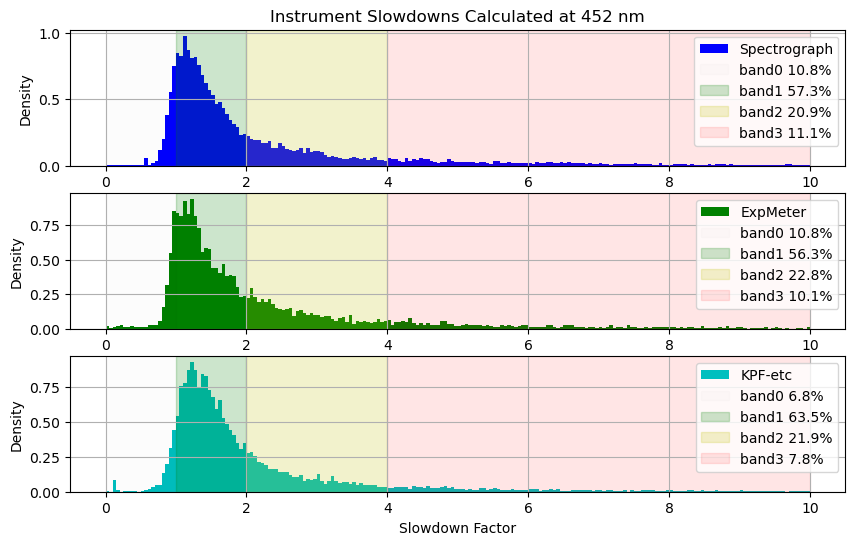

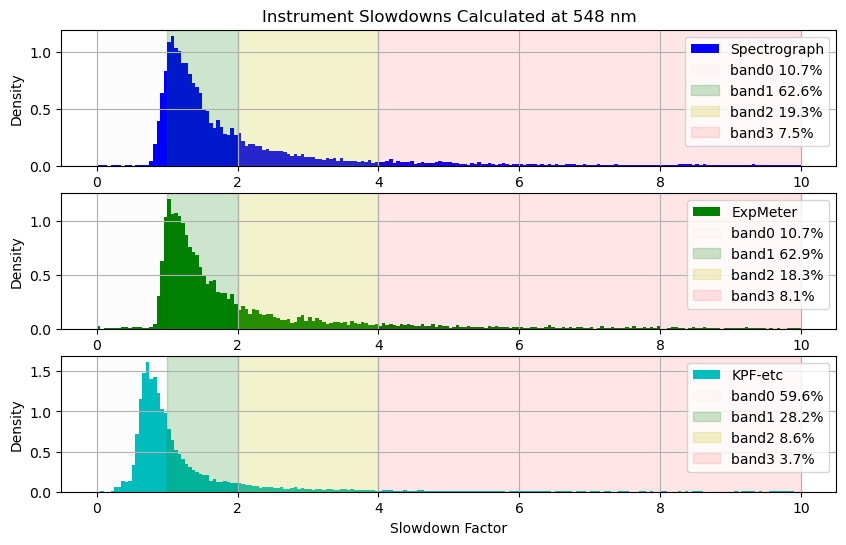

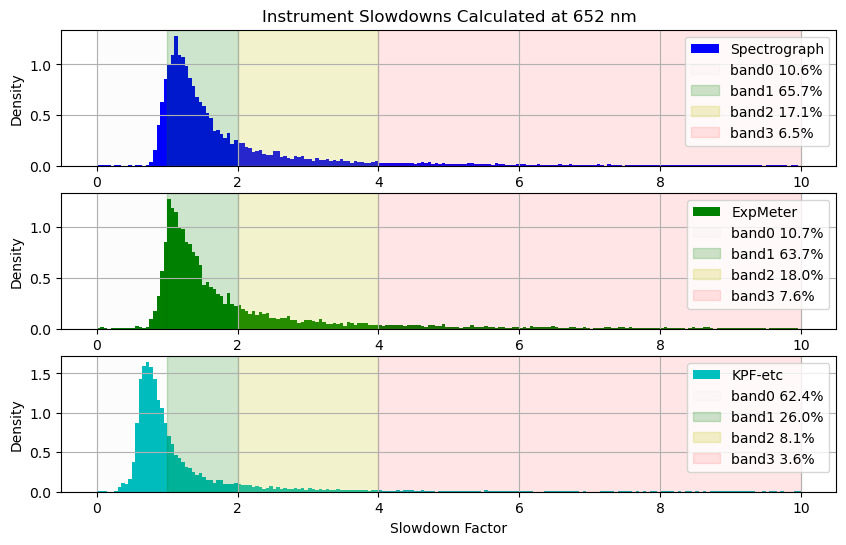

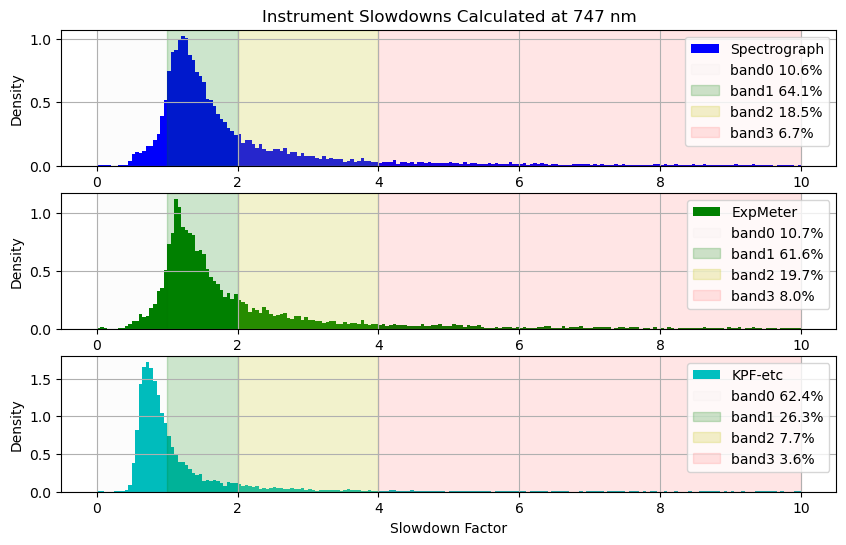

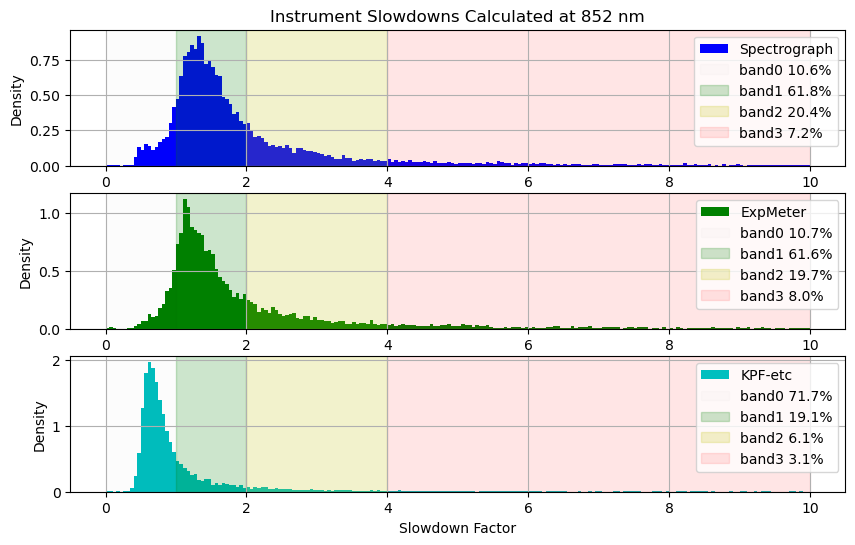

In [14]:
for wav in wavs:
    plot_slowdowns(t, wav)

### Discussion: Spectrograph and Exposure Meter Slowdowns

We see that the slowdown factors for both the instrument or the exposure meter are typically >1.  This is to be expected as our nominal zero points are the 90th percentile of good data, so the Zero Point ETC assumes very good condition, thus most data are taken in somewhat worse conditions.  The distribution of slowdowns is what we'd expect given the distribution of Zero Points we measured before.

We have highlighted the weather bands as defined by their slowdown rate and put the percentage of observations in each band in the legend.  The majority of observations take place in band1 as we would expect.  The "band0" designation is for observations with a slowdown of <1 which should probably be considered part of band1, but is nominally out of the definied range.

Comparing the distribution of exposure meter slowdowns to instrument slow downs, we see that the exposure meter is typically a bit optimistic relative to the instrument by 10-15%, so the actual slowdown is a bit worse than one estimated in real time by the Exposure Meter.

### Discussion: KPF-etc Calculated Slowdowns

For all wavelengths other than 452nm, under good conditions, the formal KPF-etc underestimates the flux relative to what is actually observed leading to a "slowdown" of less than 1, putting most of the observations in "band0".

# Look at Ratio of Actual Slowdown (from Spectrograph ZPETC) versus Exposure Meter

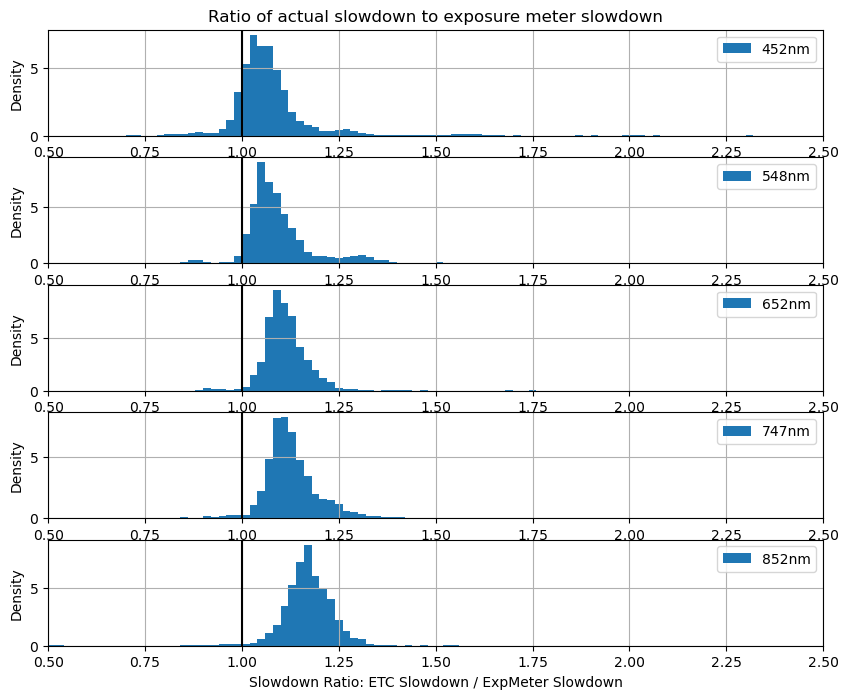

In [15]:
plt.figure(figsize=(10,8))
for i,wav in enumerate(wavs):
    plt.subplot(5,1,i+1)
    EMbin = best_EMbin[wav]
    if i==0: plt.title(f"Ratio of actual slowdown to exposure meter slowdown")
    ratio = t[f'SD-ZP-etc-{wav}']/t[f'SD-ZP-etc-EM{EMbin}']
    mask = t[f'SD-ZP-etc-{wav}'].mask | t[f'SD-ZP-etc-EM{EMbin}'].mask
    bins=np.arange(0,max(ratio[~mask]),0.02)
    plt.hist(ratio[~mask], bins=bins, density=True, label=f'{wav}nm')
    plt.axvline(1.0, color='k')
    plt.legend(loc='best')
    plt.xlim(0.5,2.5)
    plt.ylabel('Density')
    plt.grid()
plt.xlabel('Slowdown Ratio: ETC Slowdown / ExpMeter Slowdown')
plt.show()

### Discussion: Exposure Meter Slowdowns

Comparing exposure meter slowdown measures with the spectrograph, we can see a bias of ~5-15% toward the exposure meter underestimating the slowdown.  The real slowdown is larger than what you would get from the exposure meter at the end of the exposure.

# Save Results to Disk

In [16]:
t.write('data/Feb2026_withETCs.csv', overwrite=True)